In [23]:
import pandas as pd
import numpy as np
import glob, math
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from data     import load_data, make_features, make_windows
from model    import StockTransformer, PositionalEncoding

# Config
DATA_DIR    = Path("data/stocks")
SYMBOL      = "MSFT"
CUTOFF_DATE = "2012-01-01"
SEQ_LEN     = 30

FEATURE_DIM = 3   # log_return, ma10, volume
D_MODEL     = 64
NHEAD       = 4
NUM_LAYERS  = 3
FFN_DIM     = 256
DROPOUT     = 0.1

LR          = 1e-4
EPOCHS      = 20
BATCH_SIZE  = 64
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
df = load_data(path=DATA_DIR, cutoff_date=CUTOFF_DATE)
print("Loaded", len(df), "rows across all symbols")
df.head()

Loaded 9682099 rows across all symbols


,date,open,high,low,close,adj_close,volume,symbol
3049,2012-01-03,25.636623,26.459227,25.565092,26.094421,23.818647,4156300.0,A
3050,2012-01-04,25.858370,26.008583,25.457796,25.886982,23.629299,4651800.0,A
3051,2012-01-05,25.665236,26.695278,25.550787,26.466381,24.158173,6842600.0,A
3052,2012-01-06,26.530758,26.866953,26.330473,26.752504,24.419334,4711300.0,A
3053,2012-01-09,26.909872,27.482117,26.802574,27.453505,25.059198,4429500.0,A


Date range: 2012-01-03 00:00:00 → 2020-04-01 00:00:00


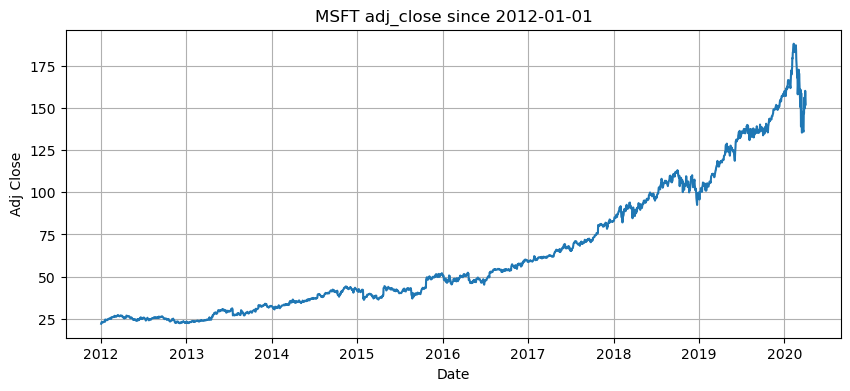

In [25]:
sub = df.query("symbol == @SYMBOL").copy()
sub = sub[sub.date >= CUTOFF_DATE].sort_values("date")
print("Date range:", sub.date.min(), "→", sub.date.max())

plt.figure(figsize=(10,4))
plt.plot(sub.date, sub["adj_close"])
plt.title(f"{SYMBOL} adj_close since {CUTOFF_DATE}")
plt.xlabel("Date"), plt.ylabel("Adj Close")
plt.grid(True)
plt.show()

In [26]:
df = load_data(path="data/stocks", cutoff_date=CUTOFF_DATE)
print(df.columns.tolist())   # should include 'adj_close'
feat = make_features(df, symbol=SYMBOL, ma_window=10)
print("Features:", feat.shape)
feat.head()

['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'symbol']
Features: (2065, 4)


,log_return,ma10,volume,target
date,,,,
2012-01-17,0.000354,22.849140,72395300.0,-0.001062
2012-01-18,-0.001062,22.969237,64860600.0,-0.003904
2012-01-19,-0.003904,23.028464,74053500.0,0.055003
2012-01-20,0.055003,23.195451,165902900.0,0.000673
2012-01-23,0.000673,23.328710,76078100.0,-0.013205


In [27]:
# split into train/val/test
n   = len(feat)
i1  = int(n * 0.70)
i2  = i1 + int(n * 0.15)
train_df = feat.iloc[:i1]
val_df   = feat.iloc[i1:i2]
test_df  = feat.iloc[i2:]

# scale
X_cols = ["log_return","ma10","volume"]
scaler_x = StandardScaler().fit(train_df[X_cols])
scaler_y = StandardScaler().fit(train_df[["target"]])

X_train = scaler_x.transform(train_df[X_cols])
y_train = scaler_y.transform(train_df[["target"]])
X_val   = scaler_x.transform(val_df[X_cols])
y_val   = scaler_y.transform(val_df[["target"]])
X_test  = scaler_x.transform(test_df[X_cols])
y_test  = scaler_y.transform(test_df[["target"]])

# make windows
X_train_win, y_train_lbl = make_windows(X_train, y_train, SEQ_LEN)
X_val_win,   y_val_lbl   = make_windows(X_val,   y_val,   SEQ_LEN)
X_test_win,  y_test_lbl  = make_windows(X_test,  y_test,  SEQ_LEN)

In [28]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self):      return len(self.y)
    def __getitem__(self,i):return self.X[i], self.y[i]

train_ds = TimeSeriesDataset(X_train_win, y_train_lbl)
val_ds   = TimeSeriesDataset(X_val_win,   y_val_lbl)
test_ds  = TimeSeriesDataset(X_test_win,  y_test_lbl)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model = StockTransformer(
    feature_dim=FEATURE_DIM,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=FFN_DIM,
    dropout=DROPOUT,
    seq_len=SEQ_LEN
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

C:\Users\denis\anaconda3\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [29]:
from train import fit

fit(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    ckpt_path="best_transformer.pth",
)

Epoch 01 | Train Loss: 1.166646 | Val Loss: 1.599527
  ↳ saved new best model
Epoch 02 | Train Loss: 1.085838 | Val Loss: 1.759300
Epoch 03 | Train Loss: 1.118419 | Val Loss: 1.588793
  ↳ saved new best model
Epoch 04 | Train Loss: 1.072999 | Val Loss: 1.614413
Epoch 05 | Train Loss: 1.045666 | Val Loss: 1.604903
Epoch 06 | Train Loss: 1.018912 | Val Loss: 1.599996
Epoch 07 | Train Loss: 1.042545 | Val Loss: 1.603321
Epoch 08 | Train Loss: 1.033088 | Val Loss: 1.607135
Epoch 09 | Train Loss: 1.054190 | Val Loss: 1.605869
Epoch 10 | Train Loss: 1.005327 | Val Loss: 1.616801
Epoch 11 | Train Loss: 1.019162 | Val Loss: 1.606031
Epoch 12 | Train Loss: 1.024411 | Val Loss: 1.625326
Epoch 13 | Train Loss: 1.025226 | Val Loss: 1.609881
Epoch 14 | Train Loss: 1.037942 | Val Loss: 1.601263
Epoch 15 | Train Loss: 1.020912 | Val Loss: 1.617891
Epoch 16 | Train Loss: 1.019568 | Val Loss: 1.618282
Epoch 17 | Train Loss: 1.018817 | Val Loss: 1.618410
Epoch 18 | Train Loss: 1.012049 | Val Loss: 1.614

Test Loss: 2.779414


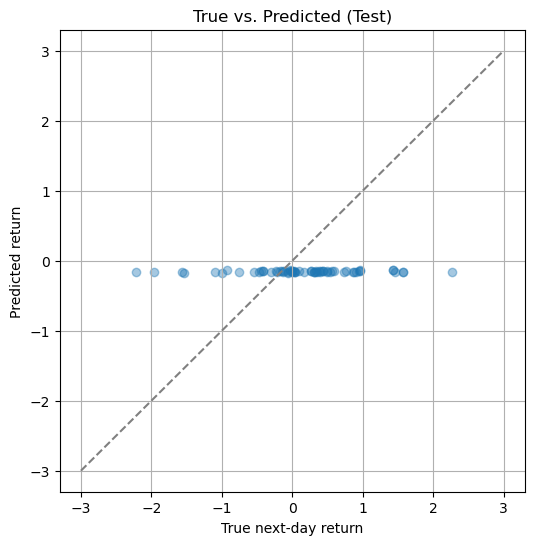

In [30]:
model.load_state_dict(torch.load("best_transformer.pth", map_location=DEVICE))
model.eval()

# compute test loss
test_loss = 0.0
with torch.no_grad():
    for Xt, yt in test_loader:
        Xt, yt = Xt.to(DEVICE).float(), yt.to(DEVICE).float()
        test_loss += criterion(model(Xt), yt).item() * Xt.size(0)
test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.6f}")

# scatter‐plot of true vs predicted (first batch)
X0, y0 = next(iter(test_loader))
with torch.no_grad():
    raw_preds = model(X0.to(DEVICE).float())
preds = raw_preds.detach().cpu().numpy().flatten()
true  = y0.numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(true, preds, alpha=0.4)
plt.plot([-3,3], [-3,3], "--", color="gray")
plt.xlabel("True next‐day return")
plt.ylabel("Predicted return")
plt.title("True vs. Predicted (Test)")
plt.grid(True)
plt.show()

In [31]:
torch.save(model.state_dict(), "final_transformer.pth")
print("Saved final model to final_transformer.pth")

Saved final model to final_transformer.pth


In [32]:
def predict_price(symbol, df, model, scaler_x, scaler_y,
                  seq_len=SEQ_LEN, ma_window=10,
                  feature_cols=["log_return","ma10","volume"]):
    # 1) rebuild features DataFrame for this symbol
    feat_df = make_features(df, symbol, ma_window=ma_window)
    
    # 2) pull raw feature matrix (n_obs × feat_dim) and scale it
    raw = feat_df[feature_cols].values                 # 2-D array
    scaled = scaler_x.transform(raw)                   # still 2-D
    
    # 3) window the *scaled* data
    X_win, _ = make_windows(scaled, feat_df["target"].values, seq_len)
    
    # 4) grab last window and move to torch
    last_win = torch.tensor(
        X_win[-1:], dtype=torch.float32, device=DEVICE
    )
    
    # 5) model inference under no_grad (returns *scaled* log-return)
    model.eval()
    with torch.no_grad():
        scaled_log_r = model(last_win).item()
    
    # 6) invert the scaling on your log-return
    log_r_pred = scaler_y.inverse_transform([[scaled_log_r]])[0][0]
    
    # 7) pull true last close from original df and compute price
    last_price = df.loc[df["symbol"]==symbol, "adj_close"].iloc[-1]
    next_price = last_price * np.exp(log_r_pred)
    
    return log_r_pred, next_price

# — now call it —
log_r, price = predict_price(SYMBOL, df, model, scaler_X, scaler_y)
print(f"Forecast next-day log-return: {log_r:.4f}")
print(f"Forecast next-day price:        {price:.2f}")

C:\Users\denis\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Forecast next-day log-return: 0.0034
Forecast next-day price:        152.63
